## instalar dependencias

In [26]:
!pip install awswrangler scikit-learn matplotlib seaborn joblib -q
!pip install sagemaker==2.232.2 -q

I0000 00:00:1778303964.673085     998 chttp2_transport.cc:1182] ipv4:169.255.255.2:45239: Got goaway [2] err=UNAVAILABLE:GOAWAY received; Error code: 2; Debug Text: Cancelling all calls {created_time:"2026-05-09T05:19:24.665918518+00:00", http2_error:2, grpc_status:14}


*** SIGTERM received at time=1778303967 on cpu 1 ***
PC: @     0x7f040c464072  (unknown)  epoll_wait
[2026-05-09 05:19:27,149 E 617 617] logging.cc:474: *** SIGTERM received at time=1778303967 on cpu 1 ***
[2026-05-09 05:19:27,149 E 617 617] logging.cc:474: PC: @     0x7f040c464072  (unknown)  epoll_wait


# IMPORTANTE REINICIAR EL KERNEL DESPUES DE ESTAS INSTALACIONES

## prueba permisos y accesos

In [1]:
import boto3

# Ver el rol actual
sts = boto3.client('sts')
identidad = sts.get_caller_identity()
print(identidad['Arn'])
# Salida ejemplo:
# arn:aws:sts::123456789:assumed-role/AmazonSageMaker-ExecutionRole-xxx/...

arn:aws:sts::219852281391:assumed-role/GlueETLMedallionRole/SageMaker


In [2]:
# Probar acceso a S3
s3 = boto3.client('s3')
try:
    buckets = s3.list_buckets()
    print("✅ S3 OK:", [b['Name'] for b in buckets['Buckets']])
except Exception as e:
    print("❌ S3 sin permiso:", e)

# Probar acceso a Athena
athena = boto3.client('athena', region_name='us-east-1')
try:
    dbs = athena.list_data_catalogs()
    print("✅ Athena OK")
except Exception as e:
    print("❌ Athena sin permiso:", e)

✅ S3 OK: ['aws-glue-assets-219852281391-us-east-1', 'cloud-ralejandro-backups', 'glue-bucket-rabm', 'glue-bucket-rues-rabm-2026', 'gmaps-screenshots-engine', 'sagemaker-us-east-1-219852281391']
✅ Athena OK


## configuración

In [3]:
import awswrangler as wr
import pandas as pd
import numpy as np

# ─── Configuración ───────────────────────────────────────────────
BUCKET   = 'glue-bucket-rues-rabm-2026'           # reemplaza con tu bucket
DATABASE = 'db_rues'
S3_OUT   = f's3://{BUCKET}/athena-results/'

# ─── Leer desde Athena ───────────────────────────────────────────
QUERY = """
    WITH base_join AS (
    SELECT
        d.matricula,
        d.codigo_camara,
        d.camara_comercio,
        d.tipo_sociedad,
        d.organizacion_juridica,
        d.categoria_matricula,
        d.actividad_economica,
        d.tipo_persona,
        f.estado_matricula,
        d.antiguedad_empresa,
        CAST(f.ultimo_ano_renovado AS bigint) AS ultimo_ano_renovado,
        f.fecha_vigencia,
        f.fecha_renovacion,
        f.fecha_actualizacion
    FROM "db_rues"."gold_dim_empresa" AS d
    INNER JOIN "db_rues"."gold_fact_renovacion" AS f
        ON d.matricula = f.matricula
    WHERE
        f.estado_matricula IN ('ACTIVA', 'RENOVADA', 'CANCELADA')
        AND d.antiguedad_empresa IS NOT NULL
        AND f.ultimo_ano_renovado IS NOT NULL
        AND d.tipo_sociedad IS NOT NULL
        AND d.actividad_economica IS NOT NULL
),

deduplicados AS (
    SELECT
        *,
        ROW_NUMBER() OVER (PARTITION BY matricula ORDER BY fecha_actualizacion DESC) AS rn
    FROM base_join
),

datos_limpios AS (
    SELECT *,
        CAST(antiguedad_empresa AS double) AS antiguedad_clean,
        CAST(YEAR(CURRENT_DATE) AS bigint) - ultimo_ano_renovado AS anos_sin_renovar,
        CASE
            WHEN antiguedad_empresa < 2 THEN 'Nueva'
            WHEN antiguedad_empresa BETWEEN 2 AND 5 THEN 'Joven'
            WHEN antiguedad_empresa BETWEEN 6 AND 10 THEN 'Establecida'
            ELSE 'Madura'
        END AS segmento_antiguedad
    FROM deduplicados
    WHERE rn = 1
)

SELECT
    tipo_sociedad,
    organizacion_juridica,
    actividad_economica,
    segmento_antiguedad,
    antiguedad_clean       AS antiguedad_empresa,
    anos_sin_renovar,
    camara_comercio,
    codigo_camara
FROM datos_limpios
ORDER BY RAND()
LIMIT 100000;
"""

df = wr.athena.read_sql_query(
    sql=QUERY,
    database=DATABASE,
    ctas_approach=True,          # más rápido para grandes volúmenes
    s3_output=S3_OUT
)

print(f"✅ Registros cargados: {df.shape[0]:,}")
print(f"   Columnas: {list(df.columns)}")
df.head()

2026-05-09 05:20:00,908	WARNING services.py:2137 -- WARNING: The object store is using /tmp instead of /dev/shm because /dev/shm has only 409968640 bytes available. This will harm performance! You may be able to free up space by deleting files in /dev/shm. If you are inside a Docker container, you can increase /dev/shm size by passing '--shm-size=0.80gb' to 'docker run' (or add it to the run_options list in a Ray cluster config). Make sure to set this to more than 30% of available RAM.


2026-05-09 05:20:03,084	INFO worker.py:2007 -- Started a local Ray instance.


/opt/conda/lib/python3.12/site-packages/ray/_private/worker.py:2046: FutureWarning: Tip: In future versions of Ray, Ray will no longer override accelerator visible devices env var if num_gpus=0 or num_gpus=None (default). To enable this behavior and turn off this error message, set RAY_ACCEL_ENV_VAR_OVERRIDE_ON_ZERO=0
  warnings.warn(


✅ Registros cargados: 100,000
   Columnas: ['tipo_sociedad', 'organizacion_juridica', 'actividad_economica', 'segmento_antiguedad', 'antiguedad_empresa', 'anos_sin_renovar', 'camara_comercio', 'codigo_camara']


,tipo_sociedad,organizacion_juridica,actividad_economica,segmento_antiguedad,antiguedad_empresa,anos_sin_renovar,camara_comercio,codigo_camara
0,SOCIEDAD COMERCIAL,PERSONA NATURAL,Alquiler y arrendamiento de otros tipos de maq...,Madura,18.0,7,BOGOTA,04
1,SOCIEDAD COMERCIAL,PERSONA NATURAL,Actividades inmobiliarias realizadas con biene...,Nueva,1.0,1,BARRANQUILLA,03
2,SOCIEDAD COMERCIAL,PERSONA NATURAL,Transporte de carga por carretera.,Joven,3.0,1,BOGOTA,04
3,SOCIEDAD COMERCIAL,SOCIEDADES POR ACCIONES SIMPLIFICADAS SAS,Transporte de carga por carretera.,Joven,4.0,1,CALI,08
4,SOCIEDAD COMERCIAL,SOCIEDADES POR ACCIONES SIMPLIFICADAS SAS,Actividades de las agencias de viaje.,Madura,13.0,12,PEREIRA,27


## preparar datos para kmeans

In [4]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Columnas para el modelo
FEATURES = [
    'tipo_sociedad',
    'organizacion_juridica',
    'actividad_economica',
    'segmento_antiguedad',
    'antiguedad_empresa',
    'anos_sin_renovar'
]

CATEGORICAS = [
    'tipo_sociedad',
    'organizacion_juridica',
    'actividad_economica',
    'segmento_antiguedad'
]

df_model = df[FEATURES].dropna().copy()

# Codificar categóricas
encoders = {}
for col in CATEGORICAS:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col].astype(str))
    encoders[col] = le  # guardar para inferencia posterior

# Escalar todas las variables
scaler = StandardScaler()
X = scaler.fit_transform(df_model)

print(f"✅ Matriz lista para K-Means: {X.shape}")

✅ Matriz lista para K-Means: (99985, 6)


## elegir número de clusters

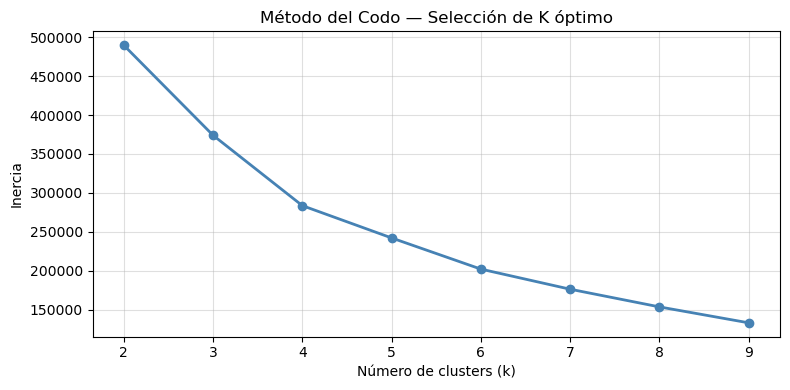

In [5]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

inertias   = []
silhouettes = []
K_RANGE    = range(2, 10)

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)
    inertias.append(km.inertia_)

# Gráfica del codo
plt.figure(figsize=(8, 4))
plt.plot(K_RANGE, inertias, marker='o', color='steelblue', linewidth=2)
plt.xlabel('Número de clusters (k)')
plt.ylabel('Inercia')
plt.title('Método del Codo — Selección de K óptimo')
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('elbow_curve.png', dpi=150)
plt.show()

## Entrenar modelo

In [6]:
K_OPTIMO = 4  # ajusta según la gráfica del codo

km_final = KMeans(
    n_clusters=K_OPTIMO,
    random_state=42,
    n_init=10,
    max_iter=300
)

df_model['cluster'] = km_final.fit_predict(X)

# Distribución por cluster
print("Distribución de empresas por cluster:")
print(df_model['cluster'].value_counts().sort_index())

Distribución de empresas por cluster:
cluster
0     3979
1    43384
2     7103
3    45519
Name: count, dtype: int64


## interpretar clusters como perfiles

In [7]:
# Pegar cluster al dataframe original
df_resultado = df[FEATURES].dropna().copy()
df_resultado['cluster'] = df_model['cluster'].values

# Resumen estadístico por cluster
perfil = df_resultado.groupby('cluster').agg(
    total_empresas=('antiguedad_empresa', 'count'),
    antiguedad_promedio=('antiguedad_empresa', 'mean'),
    anos_sin_renovar_prom=('anos_sin_renovar', 'mean'),
    tipo_sociedad_frecuente=('tipo_sociedad', lambda x: x.value_counts().index[0]),
    actividad_frecuente=('actividad_economica', lambda x: x.value_counts().index[0]),
    segmento_frecuente=('segmento_antiguedad', lambda x: x.value_counts().index[0])
).round(2)

print(perfil)

         total_empresas  antiguedad_promedio  anos_sin_renovar_prom  \
cluster                                                               
0                  3979                13.16                 117.72   
1                 43384                 5.94                   3.18   
2                  7103                 7.82                 2026.0   
3                 45519                16.16                   7.62   

            tipo_sociedad_frecuente  \
cluster                               
0        ENTIDAD SIN ANIMO DE LUCRO   
1                SOCIEDAD COMERCIAL   
2                SOCIEDAD COMERCIAL   
3                SOCIEDAD COMERCIAL   

                                       actividad_frecuente segmento_frecuente  
cluster                                                                        
0                 Actividades de otras asociaciones n.c.p.             Madura  
1        Comercio al por menor en establecimientos no e...        Establecida  
2        Expendio 

## etiquetar clusters

In [8]:
# Asignar nombres a los clusters manualmente
nombres_cluster = {
    0: 'Comercial madura',
    1: 'Comercial establecida',
    2: 'Sin fines de lucro Madura',
    3: 'Comercial joven'
}
df_resultado['perfil'] = df_resultado['cluster'].map(nombres_cluster)

In [9]:
import joblib, boto3, os, tarfile

S3_MODELOS = f's3://{BUCKET}/modelos/kmeans/'

# Guardar artefactos localmente
joblib.dump(km_final, 'kmeans_model.joblib')
joblib.dump(scaler,   'scaler.joblib')
joblib.dump(encoders, 'encoders.joblib')

# Empaquetar en .tar.gz (formato requerido por SageMaker)
with tarfile.open('model.tar.gz', 'w:gz') as tar:
    tar.add('kmeans_model.joblib')
    tar.add('scaler.joblib')
    tar.add('encoders.joblib')

# Subir a S3
s3 = boto3.client('s3')
s3.upload_file('model.tar.gz', BUCKET, 'modelos/kmeans/model.tar.gz')

# Guardar también los resultados
wr.s3.to_csv(
    df=df_resultado,
    path=f'{S3_MODELOS}resultados/kmeans_perfiles.csv',
    index=False
)

print("✅ Modelo y resultados guardados en S3")

✅ Modelo y resultados guardados en S3


## crear archivo de inferencia

In [10]:
%%writefile inference.py
import joblib
import json
import numpy as np
import os

PERFILES = {
    0: {'nombre': 'Nuevas al día',        'descripcion': 'Empresas jóvenes con renovación puntual'},
    1: {'nombre': 'Maduras en riesgo',    'descripcion': 'Empresas antiguas con varios años sin renovar'},
    2: {'nombre': 'Estables',             'descripcion': 'Empresas establecidas con renovación regular'},
    3: {'nombre': 'Nuevas abandonadas',   'descripcion': 'Empresas recientes que dejaron de renovar'}
}

def model_fn(model_dir):
    model  = joblib.load(os.path.join(model_dir, 'kmeans_model.joblib'))
    scaler = joblib.load(os.path.join(model_dir, 'scaler.joblib'))
    return {'model': model, 'scaler': scaler}

def input_fn(request_body, content_type):
    if isinstance(request_body, bytes):
        request_body = request_body.decode('utf-8')

    print(f"DEBUG content_type: {content_type}")
    print(f"DEBUG request_body: {request_body}")

    body = json.loads(request_body)

    if 'instancias' in body:
        data = body['instancias']
    elif 'instances' in body:
        data = body['instances']
    else:
        data = body

    return np.array(data, dtype=float)

def predict_fn(input_data, artifacts):
    X_scaled = artifacts['scaler'].transform(input_data)
    clusters = artifacts['model'].predict(X_scaled)
    return clusters.tolist()

def output_fn(prediction, accept):
    resultado = []
    for cluster in prediction:
        perfil = PERFILES.get(cluster, {'nombre': 'Desconocido', 'descripcion': 'Sin clasificación'})
        resultado.append({
            'cluster':     cluster,
            'perfil':      perfil['nombre'],
            'descripcion': perfil['descripcion']
        })
    return json.dumps({'predicciones': resultado})

Overwriting inference.py


## verificar sagemaker

In [11]:
import sagemaker
from sagemaker.sklearn.model import SKLearnModel

print(sagemaker.__version__)
# Debe mostrar: 2.232.2

sagemaker.config INFO - Not applying SDK defaults from location: /etc/xdg/sagemaker/config.yaml


sagemaker.config INFO - Not applying SDK defaults from location: /home/sagemaker-user/.config/sagemaker/config.yaml


2.232.2


## despliega endpoint en sageMaker

In [12]:
import boto3, sagemaker, tarfile
from sagemaker.sklearn.model import SKLearnModel

sm_client = boto3.client('sagemaker', region_name='us-east-1')

# 1. Eliminar endpoint (si aún existe)
try:
    sm_client.delete_endpoint(EndpointName='kmeans-perfiles-empresas')
    print("🗑️ Endpoint eliminado")
except:
    print("⚠️ Endpoint ya no existe")

# 2. Eliminar endpoint config (esto es lo que faltaba)
try:
    sm_client.delete_endpoint_config(EndpointConfigName='kmeans-perfiles-empresas')
    print("🗑️ Endpoint config eliminado")
except:
    print("⚠️ Endpoint config ya no existe")

# 3. Esperar unos segundos
import time
time.sleep(10)

# 4. Redesplegar
ROLE = sagemaker.get_execution_role()
sklearn_model = SKLearnModel(
    model_data=f's3://{BUCKET}/modelos/kmeans/model_final.tar.gz',
    role=ROLE,
    entry_point='inference.py',
    framework_version='1.2-1',
    sagemaker_session=sagemaker.Session()
)

predictor = sklearn_model.deploy(
    instance_type='ml.t2.medium',
    initial_instance_count=1,
    endpoint_name='kmeans-perfiles-empresas'
)

print(f"✅ Endpoint activo: {predictor.endpoint_name}")

🗑️ Endpoint eliminado


🗑️ Endpoint config eliminado


-

-

-

...

-

-

-

!

✅ Endpoint activo: kmeans-perfiles-empresas


## probar el endporit desde memoria del colab

In [14]:
from sagemaker.predictor import Predictor
from sagemaker.serializers import JSONSerializer
from sagemaker.deserializers import JSONDeserializer

# Recrear predictor con serializers explícitos
predictor = Predictor(
    endpoint_name='kmeans-perfiles-empresas',
    sagemaker_session=sagemaker.Session(),
    serializer=JSONSerializer(),
    deserializer=JSONDeserializer()
)

payload = {
    "instancias": [
        [0, 1, 5, 2, 3.5, 1.0],
        [2, 0, 3, 3, 12.0, 4.2]
    ]
}

response = predictor.predict(payload)
print("Predicciones:", response)

Predicciones: {'predicciones': [{'cluster': 0, 'perfil': 'Nuevas al día', 'descripcion': 'Empresas jóvenes con renovación puntual'}, {'cluster': 0, 'perfil': 'Nuevas al día', 'descripcion': 'Empresas jóvenes con renovación puntual'}]}


## revisar logs del endpoint (por si sale error)

In [23]:
import boto3, time

logs = boto3.client('logs', region_name='us-east-1')

streams = logs.describe_log_streams(
    logGroupName='/aws/sagemaker/Endpoints/kmeans-perfiles-empresas',
    orderBy='LastEventTime',
    descending=True,
    limit=1
)

events = logs.get_log_events(
    logGroupName='/aws/sagemaker/Endpoints/kmeans-perfiles-empresas',
    logStreamName=streams['logStreams'][0]['logStreamName'],
    limit=50
)

print("=== LOGS DEL ENDPOINT ===")
for e in events['events']:
    print(e['message'])

=== LOGS DEL ENDPOINT ===
169.254.178.2 - - [09/May/2026:04:55:08 +0000] "GET /ping HTTP/1.1" 200 0 "-" "AHC/2.0"
169.254.178.2 - - [09/May/2026:04:55:13 +0000] "GET /ping HTTP/1.1" 200 0 "-" "AHC/2.0"
169.254.178.2 - - [09/May/2026:04:55:18 +0000] "GET /ping HTTP/1.1" 200 0 "-" "AHC/2.0"
169.254.178.2 - - [09/May/2026:04:55:23 +0000] "GET /ping HTTP/1.1" 200 0 "-" "AHC/2.0"
169.254.178.2 - - [09/May/2026:04:55:28 +0000] "GET /ping HTTP/1.1" 200 0 "-" "AHC/2.0"
169.254.178.2 - - [09/May/2026:04:55:33 +0000] "GET /ping HTTP/1.1" 200 0 "-" "AHC/2.0"
169.254.178.2 - - [09/May/2026:04:55:38 +0000] "GET /ping HTTP/1.1" 200 0 "-" "AHC/2.0"
169.254.178.2 - - [09/May/2026:04:55:43 +0000] "GET /ping HTTP/1.1" 200 0 "-" "AHC/2.0"
169.254.178.2 - - [09/May/2026:04:55:48 +0000] "GET /ping HTTP/1.1" 200 0 "-" "AHC/2.0"
169.254.178.2 - - [09/May/2026:04:55:53 +0000] "GET /ping HTTP/1.1" 200 0 "-" "AHC/2.0"
169.254.178.2 - - [09/May/2026:04:55:58 +0000] "GET /ping HTTP/1.1" 200 0 "-" "AHC/2.0"
169.25

## eliminar endponit si ya no se usa

In [15]:
# 1. Eliminar endpoint (si aún existe)
try:
    sm_client.delete_endpoint(EndpointName='kmeans-perfiles-empresas')
    print("🗑️ Endpoint eliminado")
except:
    print("⚠️ Endpoint ya no existe")

# 2. Eliminar endpoint config (esto es lo que faltaba)
try:
    sm_client.delete_endpoint_config(EndpointConfigName='kmeans-perfiles-empresas')
    print("🗑️ Endpoint config eliminado")
except:
    print("⚠️ Endpoint config ya no existe")

🗑️ Endpoint eliminado
🗑️ Endpoint config eliminado
